In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


# Notebook 1 — Data & Standard Training

**Goal:** Train a standard ResNet-18 on CIFAR-10 from scratch and save the best checkpoint.

**Data source:** Kaggle competition dataset at `/kaggle/input/competitions/cifar-10/`
- `train.7z` → 60,000 PNG images (32×32)
- `trainLabels.csv` → image ID to class label mapping

**Split:** 50,000 train / 5,000 test / 5,000 validation (stratified)

**Environment:** Kaggle GPU (T4/P100) recommended.

**Outputs:**
- `outputs/checkpoints/standard_resnet18.pth` — best epoch weights
- `outputs/training_curves/standard_train.csv` — per-epoch metrics

**Expected result:** Clean test accuracy ≥ 90% (30 epochs on GPU)

---
## Cell 1 — Imports & Config

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import subprocess
import os
import time
import glob

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Hyperparameters ──
BATCH_SIZE = 128
EPOCHS = 30           # 20-40 epochs sufficient on GPU; targets ~90%+ clean accuracy
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Kaggle input paths ──
KAGGLE_INPUT = '/kaggle/input/competitions/cifar-10'
TRAIN_ARCHIVE = f'{KAGGLE_INPUT}/train.7z'
LABELS_CSV    = f'{KAGGLE_INPUT}/trainLabels.csv'

# ── Extraction directory (writable area on Kaggle) ──
EXTRACT_DIR = '/kaggle/working/cifar10_extracted'
TRAIN_IMG_DIR = f'{EXTRACT_DIR}/train'

# ── Output paths ──
IS_KAGGLE = os.path.exists('/kaggle/working')
OUTPUT_DIR = '/kaggle/working/outputs' if IS_KAGGLE else '../outputs'

CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
CURVES_DIR = f'{OUTPUT_DIR}/training_curves'
CHECKPOINT_PATH = '/kaggle/working/standard_resnet18.pth'
CURVES_PATH = f'{CURVES_DIR}/standard_train.csv'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CURVES_DIR, exist_ok=True)

print(f"Training on: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Kaggle environment: {IS_KAGGLE}")

Training on: cuda
Output directory: /kaggle/working/outputs
Kaggle environment: True


---
## Cell 2 — Extract Dataset

Extract `train.7z` from the Kaggle competition input. This produces individual PNG files (32×32) named `1.png`, `2.png`, ... inside the extraction directory.

In [4]:
# ── Extract train.7z if not already extracted ──
os.makedirs(EXTRACT_DIR, exist_ok=True)

if os.path.exists(TRAIN_IMG_DIR) and len(os.listdir(TRAIN_IMG_DIR)) > 0:
    print(f"Train images already extracted at {TRAIN_IMG_DIR}")
else:
    print(f"Extracting {TRAIN_ARCHIVE} ...")
    result = subprocess.run(
        ['7z', 'x', TRAIN_ARCHIVE, f'-o{EXTRACT_DIR}', '-y'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"Error extracting: {result.stderr}")
        raise RuntimeError("Failed to extract train.7z")
    print("Extraction complete.")

# Verify extraction
num_images = len(glob.glob(f'{TRAIN_IMG_DIR}/*.png'))
print(f"Total images found: {num_images:,}")

# Load labels CSV
labels_df = pd.read_csv(LABELS_CSV)
print(f"Labels CSV shape: {labels_df.shape}")
print(f"\nLabel distribution:\n{labels_df['label'].value_counts().sort_index()}")
print(f"\nSample rows:")
labels_df.head()

Extracting /kaggle/input/competitions/cifar-10/train.7z ...
Extraction complete.
Total images found: 50,000
Labels CSV shape: (50000, 2)

Label distribution:
label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64

Sample rows:


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


---
## Cell 3 — Custom Dataset & Stratified Split

- Custom `CIFAR10Dataset` class that loads individual PNG files and maps text labels to integer indices.
- **Stratified split:** 50,000 train / 5,000 test / 5,000 validation — preserves class balance across all splits.

In [25]:
# ── CIFAR-10 constants ──
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CIFAR10_CLASSES)}


class CIFAR10Dataset(Dataset):
    """
    Custom PyTorch Dataset for CIFAR-10 PNG images from the Kaggle competition.
    Each image is a 32x32 PNG file named by its ID (e.g., 1.png, 2.png, ...).
    """
    def __init__(self, image_ids, labels, img_dir, transform=None):
        self.image_ids = image_ids
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, f'{img_id}.png')
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label


# ── Prepare IDs and integer labels ──
all_ids = labels_df['id'].values
all_labels = labels_df['label'].map(CLASS_TO_IDX).values

print(f"Total samples: {len(all_ids):,}")
print(f"Unique classes: {len(set(all_labels))}")

Total samples: 50,000
Unique classes: 10


In [26]:
from sklearn.model_selection import train_test_split

# Step 1: Split off 10,000 (val + test) from 50,000
train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    all_ids, all_labels,
    test_size=10000,   # 50k → 40k train + 10k temp
    random_state=SEED,
    stratify=all_labels
)

# Step 2: Split 10,000 → 5k val + 5k test
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels,
    test_size=5000,    # split evenly
    random_state=SEED,
    stratify=temp_labels
)

print(f"Train: {len(train_ids):,}  |  Val: {len(val_ids):,}  |  Test: {len(test_ids):,}")
print(f"Total: {len(train_ids) + len(val_ids) + len(test_ids):,}")

Train: 40,000  |  Val: 5,000  |  Test: 5,000
Total: 50,000


---
## Cell 4 — DataLoaders

- **Train:** Normalize + RandomCrop (padding=4) + RandomHorizontalFlip
- **Test/Val:** Normalize only (no augmentation)

In [27]:
# ── Transforms ──
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# ── Datasets ──
train_dataset = CIFAR10Dataset(train_ids, train_labels, TRAIN_IMG_DIR, transform=train_transform)
test_dataset  = CIFAR10Dataset(test_ids,  test_labels,  TRAIN_IMG_DIR, transform=test_transform)
val_dataset   = CIFAR10Dataset(val_ids,   val_labels,   TRAIN_IMG_DIR, transform=test_transform)

# ── DataLoaders ──
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train:  {len(train_dataset):,} samples → {len(train_loader)} batches")
print(f"Test:   {len(test_dataset):,} samples → {len(test_loader)} batches")
print(f"Val:    {len(val_dataset):,} samples → {len(val_loader)} batches")
print(f"Batch size: {BATCH_SIZE}")

Train:  40,000 samples → 313 batches
Test:   5,000 samples → 40 batches
Val:    5,000 samples → 40 batches
Batch size: 128


### Quick dataset preview

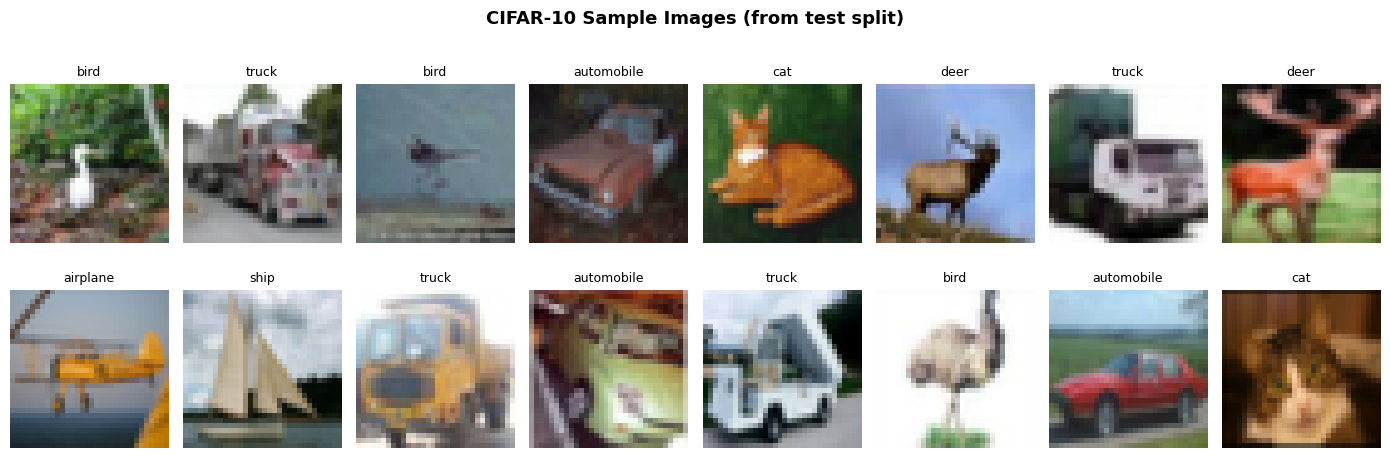

In [28]:
def denormalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    """Reverse CIFAR-10 normalization for display."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Preview 16 images from the test set
preview_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)
images, labels = next(iter(preview_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images (from test split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 5 — Model Definition

ResNet-18 adapted for CIFAR-10's 32×32 inputs:
- **No pretrained weights** — trained from scratch on CIFAR-10
- Replace `conv1` with a 3×3 kernel (stride=1) instead of 7×7 (designed for 224×224 ImageNet)
- Remove `maxpool` (set to `nn.Identity()`) — the 32×32 images are too small for aggressive downsampling
- Replace final FC layer: `model.fc = nn.Linear(512, 10)`

These modifications are standard practice for CIFAR-10 and improve clean accuracy by ~1-2%.

In [29]:
def create_resnet18_cifar10():
    """
    Create a ResNet-18 model adapted for CIFAR-10 (32x32 images, 10 classes).
    Modifications from standard ImageNet ResNet-18:
      - conv1: 3x3 kernel, stride=1, padding=1 (instead of 7x7, stride=2)
      - maxpool: removed (nn.Identity)
      - fc: 512 -> 10 (instead of 512 -> 1000)
    """
    model = models.resnet18(weights=None)  # train from scratch, no pretrained

    # Replace first conv: 7x7 stride 2 → 3x3 stride 1 (for 32x32 inputs)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Remove maxpool — too aggressive for 32x32
    model.maxpool = nn.Identity()

    # Replace classifier head: 1000 → 10 classes
    model.fc = nn.Linear(512, 10)

    return model

model = create_resnet18_cifar10().to(DEVICE)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResNet-18 (CIFAR-10 adapted)")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {DEVICE}")

Model: ResNet-18 (CIFAR-10 adapted)
Total parameters:     11,173,962
Trainable parameters: 11,173,962
Device: cuda


---
## Cell 6 — Training Loop

- **Optimizer:** SGD with momentum (0.9) and weight decay (5e-4)
- **Scheduler:** CosineAnnealingLR — smoothly decays LR from 0.1 to near 0
- **Checkpointing:** Save the best model by test accuracy (not just last epoch)
- **Validation:** Used to monitor for overfitting (not used for model selection)

In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (average_loss, accuracy%)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset. Returns (average_loss, accuracy%)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [ ]:
# ── Setup ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {
    'epoch': [], 'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'lr': []
}

start_time = time.time()

print(f"Starting training for {EPOCHS} epochs...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8} | {'Time':>6}")
print('-' * 75)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    elapsed = time.time() - epoch_start
    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.2f}% | {val_loss:8.4f} | {val_acc:6.2f}% | {current_lr:.6f} | {elapsed:.1f}s")

Starting training for 30 epochs...
Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
---------------------------------------------------------------------------
    1 |     2.0071 |    28.60% |   1.5826 |  41.56% | 0.100000 | 38.0s
    2 |     1.4925 |    44.98% |   1.2780 |  53.44% | 0.099726 | 36.9s
    3 |     1.2453 |    54.75% |   1.3072 |  54.16% | 0.098907 | 36.7s
    4 |     1.0083 |    63.98% |   1.1002 |  61.18% | 0.097553 | 37.1s
    5 |     0.8529 |    70.03% |   0.9767 |  66.88% | 0.095677 | 36.8s
    6 |     0.7346 |    74.38% |   0.7895 |  72.74% | 0.093301 | 37.0s
    7 |     0.6491 |    77.56% |   0.7212 |  75.84% | 0.090451 | 36.9s
    8 |     0.5858 |    79.69% |   0.6138 |  79.24% | 0.087157 | 36.9s
    9 |     0.5369 |    81.57% |   0.6307 |  78.16% | 0.083457 | 36.7s
   10 |     0.5052 |    82.60% |   0.6184 |  78.78% | 0.079389 | 36.9s
   11 |     0.4772 |    83.37% |   0.6857 |  77.80% | 0.075000 | 36.9s
   12 |     0.4467 |    84.61% |   0

RuntimeError: Parent directory /kaggle/working/outputs does not exist.

In [ ]:
torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f"\nTraining complete in {(time.time()-start_time)/60:.1f} min")
print(f"Last epoch val accuracy : {history['val_acc'][-1]:.2f}%")
print(f"Checkpoint saved        : {CHECKPOINT_PATH}")

best_val_acc = history['val_acc'][-1]


Training complete in 26.0 min
Last epoch val accuracy : 92.88%
Checkpoint saved        : /kaggle/working/outputs/standard_resnet18.pth


---
## Cell 7 — Save Checkpoint & Training Curves

In [43]:
# Save training curves to CSV
df_history = pd.DataFrame(history)
df_history.to_csv(CURVES_PATH, index=False)

---
## Cell 8 — Plot Training Curves

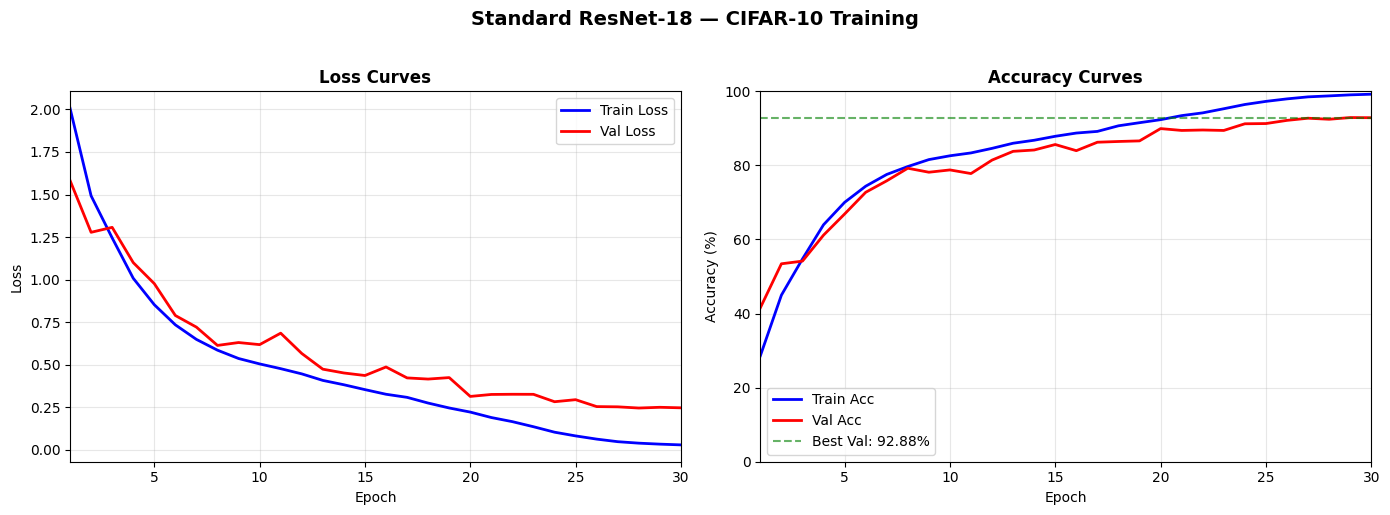

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_history['epoch'], df_history['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax1.plot(df_history['epoch'], df_history['val_loss'],   'r-', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_xlim(1, EPOCHS)

ax2.plot(df_history['epoch'], df_history['train_acc'], 'b-', linewidth=2, label='Train Acc')
ax2.plot(df_history['epoch'], df_history['val_acc'],   'r-', linewidth=2, label='Val Acc')
ax2.axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.6, label=f'Best Val: {best_val_acc:.2f}%')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_xlim(1, EPOCHS); ax2.set_ylim(0, 100)

plt.suptitle('Standard ResNet-18 — CIFAR-10 Training', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CURVES_DIR}/standard_train_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9 — Final Evaluation

Load the best checkpoint and confirm final test accuracy + per-class breakdown.

In [ ]:
best_model = create_resnet18_cifar10().to(DEVICE)
best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
best_model.eval()

val_loss_final,  val_acc_final  = evaluate(best_model, val_loader,  criterion, DEVICE)
test_loss_final, test_acc_final = evaluate(best_model, test_loader, criterion, DEVICE)

print("=" * 52)
print("  Standard Model — Final Evaluation")
print("=" * 52)
print(f"  Val accuracy  (checkpoint basis) : {val_acc_final:.2f}%")
print(f"  Test accuracy (final result)     : {test_acc_final:.2f}%")
print(f"  Expected range                   : 90–93%")
print("=" * 52)

# Per-class on test set
class_correct = [0] * 10
class_total   = [0] * 10
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        _, predicted = best_model(images).max(1)
        for i in range(labels.size(0)):
            class_correct[labels[i]] += (predicted[i] == labels[i]).item()
            class_total[labels[i]]   += 1

print(f"\nPer-class accuracy (test set):")
print(f"{'Class':<12} | {'Correct':>7} / {'Total':>5} | {'Acc':>7}")
print('-' * 38)
for i in range(10):
    acc = 100.0 * class_correct[i] / class_total[i]
    print(f"{CIFAR10_CLASSES[i]:<12} | {class_correct[i]:>7} / {class_total[i]:>5} | {acc:>6.2f}%")

  Standard Model — Final Evaluation
  Val accuracy  (checkpoint basis) : 92.88%
  Test accuracy (final result)     : 92.94%
  Expected range                   : 90–93%

Per-class accuracy (test set):
Class        | Correct / Total |     Acc
--------------------------------------
airplane     |     459 /   500 |  91.80%
automobile   |     483 /   500 |  96.60%
bird         |     450 /   500 |  90.00%
cat          |     424 /   500 |  84.80%
deer         |     462 /   500 |  92.40%
dog          |     444 /   500 |  88.80%
frog         |     476 /   500 |  95.20%
horse        |     474 /   500 |  94.80%
ship         |     486 /   500 |  97.20%
truck        |     489 /   500 |  97.80%


---
## Summary

| Item | Value |
|------|-------|
| Model | ResNet-18 (CIFAR-10 adapted) |
| Dataset | Kaggle CIFAR-10 competition (60K images) |
| Split | 50K train / 5K test / 5K val (stratified) |
| Epochs | 30 |
| Optimizer | SGD (lr=0.1, momentum=0.9, wd=5e-4) |
| Scheduler | CosineAnnealingLR |
| Best checkpoint | `outputs/checkpoints/standard_resnet18.pth` |
| Training curves | `outputs/training_curves/standard_train.csv` |

**Next step:** Run `02_attack_engine.ipynb` to attack this standard model.